### **Case design analysis**

Experimental case selection and protocol design for human-AI decision support system study

- Design: 18 cases × 3 protocols (within-subject)
- Each participant: 18 trials (~20 min)
- Target N: 100 participants (~33 per protocol group)

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(BASE_DIR)

from feature_config import FEATURES, TARGET

np.random.seed(42)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Working directory:", os.getcwd())

Working directory: /Users/annaasatryan/Desktop/capstone/codes/notebooks


In [2]:
df = pd.read_parquet("../../artifacts/test_predictions.parquet")

# Safety clip
df['pred_prob'] = df['pred_prob'].clip(1e-6, 1 - 1e-6)

print("Shape:", df.shape)
print("Default rate:", df['y_true'].mean().round(4))
print("Difficulty tier counts:")
print(df['difficulty_tier'].value_counts())

Shape: (479744, 14)
Default rate: 0.2288
Difficulty tier counts:
difficulty_tier
easy      241081
medium    175439
hard       63224
Name: count, dtype: int64


**Feature engineering**

In [3]:
# correctness: model correct at 0.5 threshold
#   used ONLY for case stratification, not DSS decision-making
#
# confidence: probability assigned to the predicted class
#   measures how certain the model is, regardless of direction

df['model_pred_class'] = (df['pred_prob'] >= 0.5).astype(int)
df['correct']          = (df['model_pred_class'] == df['y_true']).astype(int)

df['confidence'] = np.where(
    df['pred_prob'] >= 0.5,
    df['pred_prob'],
    1 - df['pred_prob']
)

# Confidence bins within difficulty tier
# Avoids confounding between difficulty and confidence
df['conf_bin'] = (
    df.groupby('difficulty_tier', observed=True)['confidence']
    .transform(lambda x: pd.qcut(x, q=2, labels=['low', 'high']))
)

**Validation checks**

In [4]:
print("=== ACCURACY BY DIFFICULTY ===")
print(df.groupby('difficulty_tier', observed=True)['correct'].mean().round(4))

print("\n=== CONFIDENCE BY DIFFICULTY ===")
print(df.groupby('difficulty_tier', observed=True)['confidence'].mean().round(4))

=== ACCURACY BY DIFFICULTY ===
difficulty_tier
easy      0.8629
hard      0.5888
medium    0.7014
Name: correct, dtype: float64

=== CONFIDENCE BY DIFFICULTY ===
difficulty_tier
easy      0.8877
hard      0.6284
medium    0.7334
Name: confidence, dtype: float64


**Confidence-accuracy alignment diagnostic**

In [5]:
gap = (
    df[df['correct'] == 1]['confidence'].mean()
    - df[df['correct'] == 0]['confidence'].mean()
)

print(f"Mean confidence when correct   : "
      f"{df[df['correct']==1]['confidence'].mean():.4f}")
print(f"Mean confidence when incorrect : "
      f"{df[df['correct']==0]['confidence'].mean():.4f}")
print(f"Confidence gap (correct - wrong): {gap:.4f}")

Mean confidence when correct   : 0.8170
Mean confidence when incorrect : 0.7313
Confidence gap (correct - wrong): 0.0857


  Gap of ~0.086 indicates moderate confidence-accuracy alignment.
  The model is more confident when correct than when wrong,
  but the separation is not large enough to make reliance decisions trivial.
  This creates a non-degenerate environment for studying human reliance behavior.
  Directly relevant to H5 (confidence alignment hypothesis).

**Directional error analysis**

In [6]:
df['fp'] = ((df['model_pred_class'] == 1) & (df['y_true'] == 0)).astype(int)
df['fn'] = ((df['model_pred_class'] == 0) & (df['y_true'] == 1)).astype(int)

print("=== Error types by difficulty ===")
print(df.groupby('difficulty_tier', observed=True)[['fp','fn']].mean().round(4))

=== Error types by difficulty ===
                     fp      fn
difficulty_tier                
easy             0.0000  0.1371
hard             0.1898  0.2214
medium           0.0434  0.2552


  FP = model predicts default, applicant actually paid (false alarm)
  FN = model predicts paid, applicant actually defaulted (missed default)
  FN dominates in medium/easy — model rarely predicts default at 0.5 threshold.
  This asymmetry is WHY the DSS uses probabilities, not binary decisions.

**Normative decision benchmark**

- C_FN = cost of approving a defaulting loan (missed default)
- C_FP = cost of rejecting a creditworthy loan (missed opportunity)

We set C_FN:C_FP = 5:1, consistent with standard credit risk literature where losses from defaults typically exceed foregone interest income by a ratio of 4-6x. 
This yields tau = 1/6 ≈ 0.167.

Sensitivity: results are robust across C_FN in [3, 7]; the qualitative pattern of model-optimal disagreement by difficulty tier holds across this range.

In [7]:
C_FN = 5
C_FP = 1
tau  = C_FP / (C_FP + C_FN)

df['model_decision']   = (df['pred_prob'] < 0.5).astype(int)   # 1=approve
df['optimal_decision'] = (df['pred_prob'] < tau).astype(int)   # 1=approve
df['model_optimal']    = (df['model_decision'] == df['optimal_decision']).astype(int)

print(f"Decision threshold tau: {tau:.4f}")
print(f"\nApproval rate — model (0.5):    {df['model_decision'].mean():.4f}")
print(f"Approval rate — optimal (tau):  {df['optimal_decision'].mean():.4f}")
print(f"Model-optimal disagreement:     "
      f"{(df['model_decision'] != df['optimal_decision']).mean():.4f}")

print("\n=== Model-optimal agreement by difficulty ===")
print(df.groupby('difficulty_tier', observed=True)['model_optimal'].mean().round(4))

Decision threshold tau: 0.1667

Approval rate — model (0.5):    0.9217
Approval rate — optimal (tau):  0.4408
Model-optimal disagreement:     0.4809

=== Model-optimal agreement by difficulty ===
difficulty_tier
easy      0.7987
hard      0.3758
medium    0.1865
Name: model_optimal, dtype: float64


Medium-difficulty cases show the LOWEST model-optimal agreement (18.7%), lower than even hard cases (37.6%). This is expected: medium-difficulty
cases have base rates closest to the cost-sensitive threshold tau=0.167, where the standard 0.5-threshold model most frequently disagrees with the optimal cost-sensitive rule. This is not an anomaly — it is a feature of the experimental design that makes medium cases the most decision-theoretically consequential.

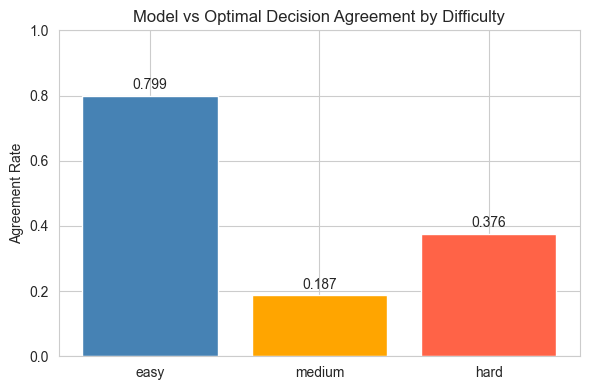

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ['easy', 'medium', 'hard']
vals  = [
    df[df['difficulty_tier'] == t]['model_optimal'].mean()
    for t in order
]
ax.bar(order, vals, color=['steelblue', 'orange', 'tomato'])
ax.set_title("Model vs Optimal Decision Agreement by Difficulty")
ax.set_ylabel("Agreement Rate")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("../visualizations/normative_agreement.png", dpi=150, bbox_inches='tight')
plt.show()

**EXPERIMENTAL DESIGN**


1. 18 cases × 3 protocols = 54 trials per participant
BUT: within-subject means each case seen ONCE per participant
Each participant completes exactly 18 trials 


2. Protocol assignment is counterbalanced:
  
  - Group 1 (n≈33): Cases 1-6 → no_ai | 7-12 → human_first | 13-18 → ai_first  
  - Group 2 (n≈33): Cases 1-6 → human_first | 7-12 → ai_first | 13-18 → no_ai  
  - Group 3 (n≈34): Cases 1-6 → ai_first | 7-12 → no_ai | 13-18 → human_first


  This ensures every case is seen under every protocol across the full sample.
  With N=100: ~33 participants per protocol condition per case cluster.


3. CASE STRATIFICATION:
  difficulty (3) × model_correctness (2) = 6 cells × 3 cases = 18 cases

  **WHY THESE CELLS:**
  - easy+correct   → baseline, participant should agree with AI
  - easy+wrong     → automation bias check (AI is confident but wrong)
  - medium+correct → moderate uncertainty, correct AI
  - medium+wrong   → medium uncertainty, wrong AI — normative gap is largest here
  - hard+correct   → under-reliance check (AI uncertain but correct)
  - hard+wrong     → highest ambiguity, wrong AI

4. Confidence is recorded as a covariate, not a design factor.
This preserves statistical power while maintaining interpretability.

**Stratified case selection**

In [9]:
N_PER_CELL = 3

# --- Filter pool ---
df_pool = df[
    (df['pred_prob'] > 0.05) &
    (df['pred_prob'] < 0.95) &
    (df['difficulty_tier'].notna()) &
    (df['purpose'] != 'other')
].copy()

print(f"Case pool after filtering: {len(df_pool):,}")
print(df_pool.groupby(['difficulty_tier', 'correct'], observed=True).size().unstack(fill_value=0))


# --- Sampling function with global distance constraint ---
def sample_cell(df, tier, correct, n, already_selected_probs=None, min_dist=0.02):
    subset = df[
        (df['difficulty_tier'] == tier) &
        (df['correct'] == correct)
    ].copy()

    if len(subset) <= n:
        return subset

    if already_selected_probs is None:
        already_selected_probs = []

    # Sorting strategy
    if tier == 'hard':
        subset = subset.sort_values('pred_prob', ascending=False)
    elif tier == 'easy' and correct == 1:
        # Prioritize low predictions to get cases below tau
        subset = subset.sort_values('pred_prob', ascending=True)
    elif 'model_optimal' in subset.columns and subset['model_optimal'].nunique() > 1:
        subset = subset.sort_values(['model_optimal', 'pred_prob'])
    else:
        subset = subset.sort_values('pred_prob')

    selected_rows = []
    selected_probs = list(already_selected_probs)
    used_purposes = set()

    # --- Pass 1: enforce distance + prefer purpose diversity ---
    for _, row in subset.iterrows():
        prob = row['pred_prob']

        if any(abs(prob - p) < min_dist for p in selected_probs):
            continue

        if row['purpose'] not in used_purposes or len(selected_rows) < n:
            selected_rows.append(row)
            selected_probs.append(prob)
            used_purposes.add(row['purpose'])

        if len(selected_rows) >= n:
            break

    # --- Pass 2: relax purpose diversity, keep distance ---
    if len(selected_rows) < n:
        remaining = subset.drop(index=[r.name for r in selected_rows])
        for _, row in remaining.iterrows():
            prob = row['pred_prob']

            if any(abs(prob - p) < min_dist for p in selected_probs):
                continue

            selected_rows.append(row)
            selected_probs.append(prob)

            if len(selected_rows) >= n:
                break

    # --- Pass 3: fully relax (guarantee fill) ---
    if len(selected_rows) < n:
        remaining = subset.drop(index=[r.name for r in selected_rows])
        remaining = remaining.sample(frac=1, random_state=42)

        for _, row in remaining.iterrows():
            selected_rows.append(row)
            if len(selected_rows) >= n:
                break

    return pd.DataFrame(selected_rows)


# Order matters: easy-correct sampled FIRST to protect low-probability cases
# before cross-cell distance constraint blocks them
cells = [
    ('easy', 1),    # need low pred_prob (below tau)
    ('hard', 1),    # need high pred_prob
    ('hard', 0),    # need high pred_prob
    ('medium', 1),  # mid-range
    ('medium', 0),  # mid-range
    ('easy', 0),    # flexible, sampled last
]


# --- Global sampling with cross-cell spacing ---
all_selected_probs = []
sampled = []

for tier, correct in cells:
    cell_df = sample_cell(
        df_pool,
        tier,
        correct,
        N_PER_CELL,
        already_selected_probs=all_selected_probs,
        min_dist=0.02
    )

    all_selected_probs.extend(cell_df['pred_prob'].tolist())
    sampled.append(cell_df)


# --- Final assembly ---
cases = (
    pd.concat(sampled)
    .drop_duplicates()
    .reset_index(drop=True)
)

cases['case_position'] = cases.index + 1

print(f"\nSELECTED: {len(cases)}")

Case pool after filtering: 417,304
correct              0       1
difficulty_tier               
easy             29621  168249
hard             24215   34277
medium           48155  112787

SELECTED: 18


In [10]:
C_FN = 5  # cost of approving a defaulter
C_FP = 1  # cost of rejecting a good loan

def compute_cost(decisions, y_true, c_fn=5, c_fp=1):
    """decisions: 1=approve, 0=reject"""
    fn = ((decisions == 1) & (y_true == 1)).sum() * c_fn
    fp = ((decisions == 0) & (y_true == 0)).sum() * c_fp
    return (fn + fp) / len(y_true)

y = cases['y_true'].values

# Strategy baselines
always_approve = np.ones(18)
always_reject = np.zeros(18)
model_05 = (cases['pred_prob'] < 0.5).astype(int).values  # approve if pred < 0.5
model_tau = (cases['pred_prob'] < tau).astype(int).values   # approve if pred < tau
random_decision = np.random.binomial(1, 0.5, 18)

print("=== EXPECTED COST PER CASE (18-case set) ===\n")
print(f"Always approve : {compute_cost(always_approve, y):.3f}")
print(f"Always reject  : {compute_cost(always_reject, y):.3f}")
print(f"Model at 0.5   : {compute_cost(model_05, y):.3f}")
print(f"Optimal at tau : {compute_cost(model_tau, y):.3f}")
print(f"Random          : {compute_cost(random_decision, y):.3f}")

=== EXPECTED COST PER CASE (18-case set) ===

Always approve : 2.500
Always reject  : 0.500
Model at 0.5   : 1.833
Optimal at tau : 0.333
Random          : 1.000


**Protocol assignment**

In [11]:
np.random.seed(42)

# Assign blocks within each (difficulty, correctness) cell
# For each of the 6 cells, there are exactly 3 cases

block_labels = ['block_1', 'block_2', 'block_3']
assignments = []

for (diff, corr), group in cases.groupby(['difficulty_tier', 'correct'], observed=True):
    group_shuffled = group.sample(frac=1, random_state=42).reset_index(drop=True)
    
    assert len(group_shuffled) == 3, (
        f"Expected 3 cases for ({diff}, correct={corr}), got {len(group_shuffled)}"
    )
    
    for i, block in enumerate(block_labels):
        row = group_shuffled.iloc[i].copy()
        row['block'] = block
        assignments.append(row)

cases = pd.DataFrame(assignments).reset_index(drop=True)

# assign case positions 
cases = cases.sort_values(['block', 'difficulty_tier', 'correct']).reset_index(drop=True)
cases['case_position'] = cases.index + 1

# protocol rotation table 
protocol_rotation = pd.DataFrame({
    'participant_group': ['group_1', 'group_2', 'group_3'],
    'block_1_protocol' : ['no_ai',       'human_first', 'ai_first'],
    'block_2_protocol' : ['human_first', 'ai_first',    'no_ai'],
    'block_3_protocol' : ['ai_first',    'no_ai',       'human_first'],
    'target_n'         : [33, 33, 34]
})

print("=== PROTOCOL ROTATION TABLE ===\n")
print(protocol_rotation.to_string(index=False))

print("\n\n=== DESIGN VERIFICATION ===\n")

=== PROTOCOL ROTATION TABLE ===

participant_group block_1_protocol block_2_protocol block_3_protocol  target_n
          group_1            no_ai      human_first         ai_first        33
          group_2      human_first         ai_first            no_ai        33
          group_3         ai_first            no_ai      human_first        34


=== DESIGN VERIFICATION ===



In [12]:
# Check 1: Block × Difficulty must be fully crossed
ct_block_diff = pd.crosstab(cases['block'], cases['difficulty_tier'])
print("Block × Difficulty (should be 2 per cell):")
print(ct_block_diff)
assert (ct_block_diff == 2).all().all(), "FAIL: Block × Difficulty not balanced!"

# Check 2: Block × Correctness must be balanced  
ct_block_corr = pd.crosstab(cases['block'], cases['correct'])
print("\nBlock × Correctness (should be 3 per cell):")
print(ct_block_corr)
assert (ct_block_corr == 3).all().all(), "FAIL: Block × Correctness not balanced!"

# Check 3: Within each block, difficulty × correctness = 1 per cell
for block in block_labels:
    sub = cases[cases['block'] == block]
    ct = pd.crosstab(sub['difficulty_tier'], sub['correct'])
    assert (ct == 1).all().all(), f"FAIL: {block} not fully crossed!"

print("\nWithin-block Difficulty × Correctness: ✓ (1 per cell in every block)")

# Check 4: Total counts
print(f"\nTotal cases: {len(cases)}")
print(f"Cases per block: {cases['block'].value_counts().to_dict()}")
print(f"y_true balance: {cases['y_true'].value_counts().to_dict()}")

print("\n=== ALL CHECKS PASSED ===")
print("\nEach participant group now sees EVERY difficulty under their assigned protocol.")
print("The protocol × difficulty interaction (H2) is identifiable within-subject.")

Block × Difficulty (should be 2 per cell):
difficulty_tier  easy  hard  medium
block                              
block_1             2     2       2
block_2             2     2       2
block_3             2     2       2

Block × Correctness (should be 3 per cell):
correct  0  1
block        
block_1  3  3
block_2  3  3
block_3  3  3

Within-block Difficulty × Correctness: ✓ (1 per cell in every block)

Total cases: 18
Cases per block: {'block_1': 6, 'block_2': 6, 'block_3': 6}
y_true balance: {1: 9, 0: 9}

=== ALL CHECKS PASSED ===

Each participant group now sees EVERY difficulty under their assigned protocol.
The protocol × difficulty interaction (H2) is identifiable within-subject.


**Distribution checks**

In [13]:
print("=== CASE DISTRIBUTION ===\n")

print("By difficulty:")
print(cases['difficulty_tier'].value_counts().sort_index())

print("\nBy correctness:")
print(cases['correct'].value_counts())

print("\nBy block:")
print(cases['block'].value_counts().sort_index())

print("\nCross-tab (difficulty × correctness):")
print(pd.crosstab(cases['difficulty_tier'], cases['correct']))

print("\nPredicted probability by cell:")
print(
    cases.groupby(
        ['difficulty_tier', 'correct'], observed=True
    )['pred_prob'].agg(['min', 'mean', 'max']).round(3)
)

print("\nConfidence by cell:")
print(
    cases.groupby(
        ['difficulty_tier', 'correct'], observed=True
    )['confidence'].agg(['min', 'mean', 'max']).round(3)
)

=== CASE DISTRIBUTION ===

By difficulty:
difficulty_tier
easy      6
hard      6
medium    6
Name: count, dtype: int64

By correctness:
correct
0    9
1    9
Name: count, dtype: int64

By block:
block
block_1    6
block_2    6
block_3    6
Name: count, dtype: int64

Cross-tab (difficulty × correctness):
correct          0  1
difficulty_tier      
easy             3  3
hard             3  3
medium           3  3

Predicted probability by cell:
                           min   mean    max
difficulty_tier correct                     
easy            0        0.312  0.338  0.370
                1        0.055  0.077  0.102
hard            0        0.822  0.844  0.868
                1        0.901  0.924  0.946
medium          0        0.234  0.264  0.289
                1        0.169  0.189  0.210

Confidence by cell:
                           min   mean    max
difficulty_tier correct                     
easy            0        0.630  0.662  0.688
                1        0.898  0.92

**Probability distribution**

In [14]:
print("\n=== PROBABILITY SUMMARY ===\n")
print(cases['pred_prob'].describe())


=== PROBABILITY SUMMARY ===

count    18.000000
mean      0.439373
std       0.334974
min       0.054726
25%       0.194111
50%       0.300441
75%       0.837689
max       0.946130
Name: pred_prob, dtype: float64


**Difficulty x correctness interaction**

=== DIFFICULTY × CORRECTNESS INTERACTION (full test set) ===

                              n  avg_pred  avg_conf  model_opt
difficulty_tier correct                                       
easy            0         33044     0.137     0.863      0.672
                1        208037     0.108     0.892      0.819
hard            0         26000     0.459     0.615      0.462
                1         37224     0.419     0.638      0.316
medium          0         52384     0.312     0.706      0.210
                1        123055     0.262     0.745      0.177


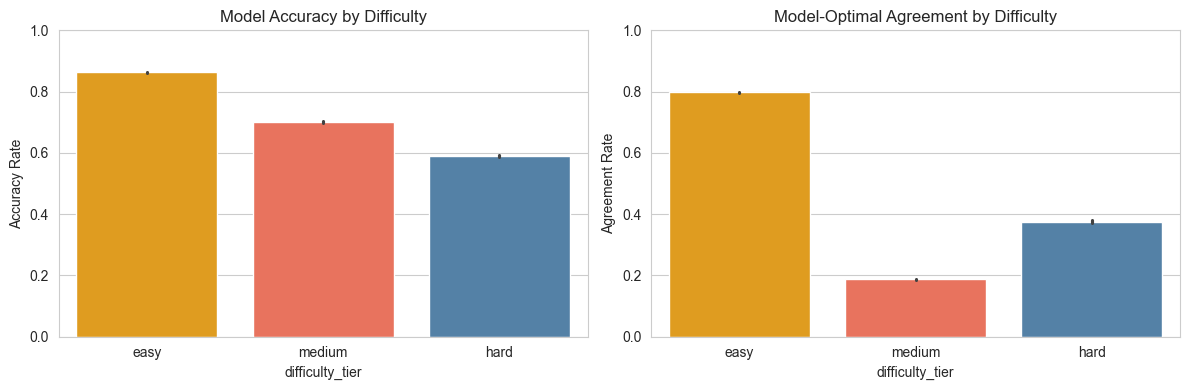

In [15]:
print("=== DIFFICULTY × CORRECTNESS INTERACTION (full test set) ===\n")
interaction = (
    df.groupby(['difficulty_tier', 'correct'], observed=True)
    .agg(
        n          =('pred_prob', 'size'),
        avg_pred   =('pred_prob', 'mean'),
        avg_conf   =('confidence','mean'),
        model_opt  =('model_optimal','mean')
    )
    .round(3)
)
print(interaction.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
sns.barplot(
    data=df, x='difficulty_tier', y='correct',
    hue='difficulty_tier', palette=['steelblue','orange','tomato'],
    ax=axes[0], legend=False, order=['easy','medium','hard']
)
axes[0].set_title("Model Accuracy by Difficulty")
axes[0].set_ylabel("Accuracy Rate")
axes[0].set_ylim(0, 1)

# Normative agreement
sns.barplot(
    data=df, x='difficulty_tier', y='model_optimal',
    hue='difficulty_tier', palette=['steelblue','orange','tomato'],
    ax=axes[1], legend=False, order=['easy','medium','hard']
)
axes[1].set_title("Model-Optimal Agreement by Difficulty")
axes[1].set_ylabel("Agreement Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../visualizations/difficulty_interactions.png", dpi=150, bbox_inches='tight')
plt.show()

**Final export**

In [16]:
os.makedirs("../../artifacts", exist_ok=True)

EXPORT_COLS = [
    'case_id', 'case_position', 'block',
    'loan_amnt', 'term', 'int_rate', 'log_annual_inc',
    'dti', 'revol_util', 'home_ownership', 'purpose',
    'credit_history_years',
    'pred_prob', 'y_true', 'difficulty_tier', 'difficulty_score',
    'correct', 'confidence', 'conf_bin', 'model_optimal'
]

final_cases = cases[[c for c in EXPORT_COLS if c in cases.columns]].copy()

final_cases.to_csv("../../artifacts/final_cases.csv", index=False)
protocol_rotation.to_csv("../../artifacts/protocol_rotation.csv", index=False)

print("Saved:")
print("  ../../artifacts/final_cases.csv")
print("  ../../artifacts/protocol_rotation.csv")
print(f"\nColumns in final_cases: {list(final_cases.columns)}")
print(f"Total cases: {len(final_cases)}")
print(f"Trials per participant: {len(final_cases)}")

Saved:
  ../../artifacts/final_cases.csv
  ../../artifacts/protocol_rotation.csv

Columns in final_cases: ['case_id', 'case_position', 'block', 'loan_amnt', 'term', 'int_rate', 'log_annual_inc', 'dti', 'revol_util', 'home_ownership', 'purpose', 'credit_history_years', 'pred_prob', 'y_true', 'difficulty_tier', 'difficulty_score', 'correct', 'confidence', 'conf_bin', 'model_optimal']
Total cases: 18
Trials per participant: 18


**Practice trials**

In [17]:
# Practice trial 1: clear non-default (very low pred_prob, y_true=0)
practice_safe = df_pool[
    (df_pool['y_true'] == 0) &
    (df_pool['pred_prob'] < 0.06) &
    (df_pool['difficulty_tier'] == 'easy')
].sample(1, random_state=42)

# Practice trial 2: clear default (high pred_prob, y_true=1)
practice_risky = df_pool[
    (df_pool['y_true'] == 1) &
    (df_pool['pred_prob'] > 0.55) &
    (df_pool['difficulty_tier'] == 'hard')
].sample(1, random_state=42)

practice_cases = pd.concat([practice_safe, practice_risky]).reset_index(drop=True)
practice_cases['case_position'] = [-2, -1]  # negative = practice
practice_cases['block'] = 'practice'

print("=== PRACTICE TRIALS ===")
print(practice_cases[['case_id', 'pred_prob', 'y_true', 'difficulty_tier', 
                        'purpose', 'loan_amnt', 'int_rate']].to_string(index=False))

practice_cases.to_csv("../../artifacts/practice_cases.csv", index=False)
print("\nSaved practice_cases.csv")

=== PRACTICE TRIALS ===
 case_id  pred_prob  y_true difficulty_tier            purpose  loan_amnt  int_rate
  731479   0.058615       0            easy             moving       5000      8.24
  252416   0.578106       1            hard debt_consolidation      22000     19.89

Saved practice_cases.csv


**Feature interpretation helpers**

In [18]:
def dti_label(dti):
    if dti < 15: return "LOW"
    elif dti < 30: return "MODERATE"
    else: return "HIGH"

def util_label(x):
    if x < 30: return "LOW"
    elif x < 70: return "MODERATE"
    else: return "HIGH"

def income_label(x):
    if x < 30000: return "LOW"
    elif x < 100000: return "MEDIUM"
    else: return "HIGH"

**Full case preview**

INSTRUCTIONS

You are acting as a loan officer.

If you approve a loan and the borrower defaults → LARGE LOSS
If you reject a good loan → SMALL LOSS

Your goal is to make decisions that minimize total loss.

Your performance will be evaluated based on decision quality.



In [19]:
def render_case(row, protocol='ai_first', show_index=True):
    income = int(np.exp(row['log_annual_inc']))
    hist = round(row['credit_history_years'], 1)
    pred_pct = int(round(row['pred_prob'] * 100))
    tier = str(row['difficulty_tier']).upper()

    # labels
    dti_l = dti_label(row['dti'])
    util_l = util_label(row['revol_util'])
    inc_l = income_label(income)

    header = ""
    if show_index:
        header = (
            f"\n{'='*60}\n"
            f"CASE {int(row['case_position']):02d} of 18 | Block: {row['block']} | [{tier}]\n"
            f"{'='*60}"
        )

    profile = (
        f"\nLOAN APPLICATION\n"
        f"{'-'*44}\n"
        f"Loan amount       : ${row['loan_amnt']:>10,.0f}\n"
        f"Interest rate     : {row['int_rate']:>9.2f}%\n"
        f"Annual income     : ${income:>10,.0f} ({inc_l})\n"
        f"Debt-to-income    : {row['dti']:>9.1f} ({dti_l})\n"
        f"Revolving util.   : {row['revol_util']:>9.1f}% ({util_l})\n"
        f"Credit history    : {hist:>7.1f} years\n"
        f"Home ownership    : {str(row['home_ownership']):>12}\n"
        f"Loan purpose      : {str(row['purpose']):>12}\n"
        f"Term              : {str(row['term']):>12}\n"
        f"{'-'*44}"
    )

    # ------------------------------------------
    # PROTOCOL LOGIC
    # ------------------------------------------

    if protocol == 'no_ai':
        decision_block = (
            f"\n\nDECISION TASK:\n"
            f"Would you APPROVE or REJECT this loan?\n"
            f"[Approve] [Reject]\n\n"
            f"(Optional) What probability do you assign to default?\n"
            f"[ 0% |-------------------| 100% ]\n\n"
            f"How confident are you? (0–100%)\n"
            f"[ 0% |-------------------| 100% ]\n"
        )

    elif protocol == 'human_first':
        decision_block = (
            f"\n\nSTEP 1 — Initial decision:\n"
            f"Would you APPROVE or REJECT?\n"
            f"[Approve] [Reject]\n\n"
            f"(Optional) Initial probability:\n"
            f"[ 0% |-------------------| 100% ]\n"
            f"[SUBMIT]\n\n"
            f"--- AI revealed ---\n\n"
            f"AI ASSESSMENT:\n"
            f"Default probability: {pred_pct}%\n\n"
            f"STEP 2 — Final decision:\n"
            f"[Approve] [Reject]\n\n"
            f"(Optional) Final probability:\n"
            f"[ 0% |-------------------| 100% ]\n\n"
            f"Confidence (0–100%):\n"
            f"[ 0% |-------------------| 100% ]\n"
        )

    else:  # ai_first
        decision_block = (
            f"\n\nAI ASSESSMENT:\n"
            f"Default probability: {pred_pct}%\n\n"
            f"DECISION TASK:\n"
            f"Would you APPROVE or REJECT?\n"
            f"[Approve] [Reject]\n\n"
            f"(Optional) Probability estimate:\n"
            f"[ 0% |-------------------| 100% ]\n\n"
            f"Confidence (0–100%):\n"
            f"[ 0% |-------------------| 100% ]\n"
        )

    footer = f"\n{'-'*44}\n[SUBMIT]\n{'='*60}\n"

    print(header + profile + decision_block + footer)

**Summary table**

In [20]:
summary = final_cases[[
    'case_position', 'block', 'difficulty_tier',
    'correct', 'pred_prob', 'confidence',
    'y_true', 'model_optimal',
    'home_ownership', 'purpose', 'loan_amnt', 'int_rate'
]].copy()

summary.columns = [
    'pos', 'block', 'difficulty',
    'model_correct', 'ai_pred', 'ai_conf',
    'true_label', 'normative_align',
    'ownership', 'purpose', 'loan_amnt', 'int_rate'
]

summary['ai_pred'] = summary['ai_pred'].round(3)
summary['ai_conf'] = summary['ai_conf'].round(3)

print("=== ALL 18 EXPERIMENTAL CASES ===\n")
print(summary.to_string(index=False))

print("\n=== KEY STATISTICS ===")
print(f"Cases where model is correct : "
      f"{int(summary['model_correct'].sum())} / 18")
print(f"Cases aligned with optimal   : "
      f"{int(summary['normative_align'].sum())} / 18")
print(f"True default rate in cases   : "
      f"{summary['true_label'].mean():.3f}")
print(f"Mean AI prediction           : "
      f"{summary['ai_pred'].mean():.3f}")
print(f"Mean AI confidence           : "
      f"{summary['ai_conf'].mean():.3f}")
print(f"Prediction range             : "
      f"[{summary['ai_pred'].min():.3f}, {summary['ai_pred'].max():.3f}]")

print("\n=== DESIGN BALANCE CHECK ===")
print(pd.crosstab(
    summary['difficulty'],
    [summary['model_correct'], summary['normative_align']],
    rownames=['difficulty'],
    colnames=['model_correct', 'normative_align']
))

=== ALL 18 EXPERIMENTAL CASES ===

 pos   block difficulty  model_correct  ai_pred  ai_conf  true_label  normative_align ownership            purpose  loan_amnt  int_rate
   1 block_1       easy              0    0.312    0.688           1                0      RENT debt_consolidation      18000     10.91
   2 block_1       easy              1    0.055    0.945           0                1  MORTGAGE debt_consolidation      11000      5.32
   3 block_1       hard              0    0.868    0.868           0                1      RENT debt_consolidation      30225     30.75
   4 block_1       hard              1    0.946    0.946           1                1       OWN        credit_card      18000     28.72
   5 block_1     medium              0    0.234    0.766           1                0      RENT             moving      11450     15.02
   6 block_1     medium              1    0.169    0.831           0                0  MORTGAGE        credit_card       4000     18.94
   7 block_2 